# Stage 2 Regularization Search Overview

Overview notebook for Stage 2 regularization search on `target_log_return_20m` with `price_hmm_n4` features.

This notebook is partial-run aware: if `stage2_results.parquet` is not present yet, it loads all available `jobs/*/metrics.json` rows.

## Current S3 Status

At notebook creation time, S3 contained a Stage 2 `main` run at `20260711_100640`: 176 completed jobs out of 288 planned jobs, with no final `stage2_results.parquet` yet. Re-run the notebook after completion; it will automatically switch to the final parquet table when available.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "build_price_feature_day.py").exists():
        PROJECT_ROOT = candidate
        break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from build_price_feature_day import make_s3_client
from analysis.stage1_model_search.stage1_analysis_tools import (
    add_composite_score,
    early_stop_curve,
    hyperparameter_importance,
    load_search_results,
    parameter_columns,
    parameter_correlations,
    parameter_summary,
    pareto_frontier,
    plot_early_stop,
    plot_heatmap,
    plot_metric_distributions,
    plot_pareto,
    plot_param_distribution,
    plot_violin_distribution,
    read_parquet,
    run_overview,
    stability_table,
    top_tables,
)

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_colwidth", 240)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
BUCKET = "binance-data-downloader"
DATASET_PREFIX = "dataset_target_20/with_price_hmm_n4"
RESULTS_SUBDIR = "stage2_regularization_search"
RUN_ID = "latest"  # or "20260711_100640"

s3 = make_s3_client()
loaded = load_search_results(
    s3=s3,
    bucket=BUCKET,
    dataset_prefix=DATASET_PREFIX,
    results_subdir=RESULTS_SUBDIR,
    run_id=RUN_ID,
    results_filename="stage2_results.parquet",
)

results = add_composite_score(loaded.results)
run_config = loaded.run_config

print(loaded.active_s3_uri)
print(f"loaded_from_final_table={loaded.loaded_from_final_table}")
print(f"rows={len(results):,}, expected={run_config.get('jobs')}")
run_config

s3://binance-data-downloader/dataset_target_20/with_price_hmm_n4/stage2_regularization_search/20260711_100640/
loaded_from_final_table=False
rows=176, expected=288


{'run_id': '20260711_100640',
 'stage': 2,
 'stage1_run_id': '20260709_204850',
 'stage1_source_prefix': 's3://binance-data-downloader/dataset_target_20/with_price_hmm_n4/stage1_architecture_search/20260709_204850/',
 'horizon': 20,
 'dataset_prefix': 'dataset_target_20/with_price_hmm_n4',
 'target_column': 'target_log_return_20m',
 'results_subdir': 'stage2_regularization_search',
 'output_prefix': 's3://binance-data-downloader/dataset_target_20/with_price_hmm_n4/stage2_regularization_search/20260711_100640/',
 'mode': 'main',
 'include_lightgbm': False,
 'max_parallel_models': 4,
 'threads_per_model': 4,
 'reserved_vcpu_hint': 16,
 'direction_threshold': 0.0025,
 'hmm_feature_prefix': 'price_hmm_n4',
 'require_hmm_features': True,
 'architecture_seeds': [{'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 10},
  {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 3},
  {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 30},
  {'depth': 4, 'learning_rate': 0.05, 'l2_leaf_reg': 10},
  {'

## 1. Completion And Cost

In [3]:
if results.empty:
    raise RuntimeError("No Stage 2 rows were loaded. Check RUN_ID and S3 prefix.")

overview = run_overview(results, run_config)
overview

,expected_jobs,completed_jobs,coverage,families,loss_functions,total_train_time_hours,median_train_time_sec,best_RMSE,median_RMSE
0,288,176,0.611111,1,1,53.199126,1096.858412,0.007153,0.007166


In [4]:
family_loss_summary = (
    results.groupby(["model_family", "loss_function"], dropna=False)
    .agg(
        jobs=("job_id", "count"),
        best_RMSE=("RMSE", "min"),
        median_RMSE=("RMSE", "median"),
        best_MAE=("MAE", "min"),
        best_DA_025=("Direction_Accuracy_0.25%", "max"),
        median_train_time=("train_time", "median"),
        total_train_time_hours=("train_time", lambda value: value.sum() / 3600),
        median_model_size_mb=("model_size_mb", "median"),
    )
    .reset_index()
    .sort_values("best_RMSE")
)
family_loss_summary

,model_family,loss_function,jobs,best_RMSE,median_RMSE,best_MAE,best_DA_025,median_train_time,total_train_time_hours,median_model_size_mb
0,catboost,RMSEWithUncertainty,176,0.007153,0.007166,0.003814,0.517994,1096.858412,53.199126,0.921638


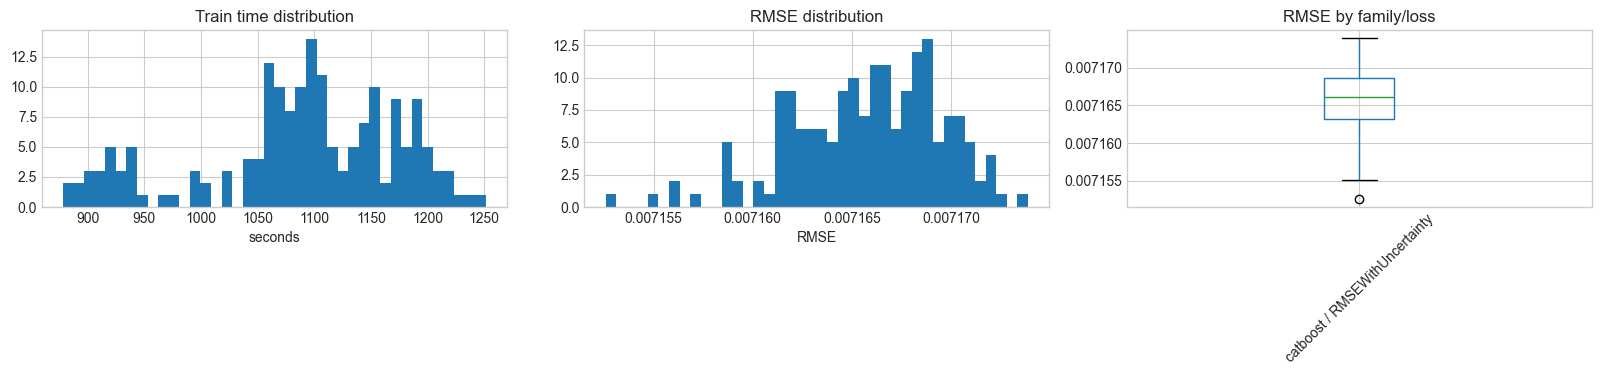

In [5]:
plot_metric_distributions(results)

## 2. Top Models

In [6]:
tops = top_tables(results, n=15)
for name, table in tops.items():
    print(f"\n{name}")
    display(table)


Top RMSE


,job_id,model_family,loss_function,RMSE,MAE,Direction_Accuracy_0.25%,CompositeScore,train_time,model_size_mb,params
120,catboost_uncertainty_seed04_reg13_d4_lr0.05_l210_bt1_rsm0.85_rs0,catboost,RMSEWithUncertainty,0.007153,0.003816,0.517134,0.784571,1168.919941,0.940632,"{""bagging_temperature"": 1, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.05, ""random_strength"": 0, ""rsm"": 0.85}"
40,catboost_uncertainty_seed02_reg05_d4_lr0.03_l23_bt0_rsm0.85_rs1,catboost,RMSEWithUncertainty,0.007155,0.003816,0.517337,0.788143,1118.245270,0.906410,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 1, ""rsm"": 0.85}"
44,catboost_uncertainty_seed02_reg09_d4_lr0.03_l23_bt0_rsm1.0_rs2,catboost,RMSEWithUncertainty,0.007156,0.003816,0.516945,0.746857,1169.453877,0.889246,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 2, ""rsm"": 1.0}"
37,catboost_uncertainty_seed02_reg02_d4_lr0.03_l23_bt0_rsm0.7_rs1,catboost,RMSEWithUncertainty,0.007156,0.003816,0.517515,0.763714,1202.929061,0.914604,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 1, ""rsm"": 0.7}"
41,catboost_uncertainty_seed02_reg06_d4_lr0.03_l23_bt0_rsm0.85_rs2,catboost,RMSEWithUncertainty,0.007157,0.003817,0.517362,0.747714,1138.517147,0.905601,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 2, ""rsm"": 0.85}"
5,catboost_uncertainty_seed01_reg06_d4_lr0.03_l210_bt0_rsm0.85_rs2,catboost,RMSEWithUncertainty,0.007159,0.003816,0.516774,0.740429,1088.453701,0.904624,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 2, ""rsm"": 0.85}"
15,catboost_uncertainty_seed01_reg16_d4_lr0.03_l210_bt1_rsm1.0_rs0,catboost,RMSEWithUncertainty,0.007159,0.003816,0.516462,0.744429,1063.534721,0.933820,"{""bagging_temperature"": 1, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 1.0}"
39,catboost_uncertainty_seed02_reg04_d4_lr0.03_l23_bt0_rsm0.85_rs0,catboost,RMSEWithUncertainty,0.007159,0.003817,0.517253,0.741286,1218.497837,0.896028,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 0.85}"
0,catboost_uncertainty_seed01_reg01_d4_lr0.03_l210_bt0_rsm0.7_rs0,catboost,RMSEWithUncertainty,0.007159,0.003815,0.517881,0.867714,1186.850101,0.908237,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 0.7}"
36,catboost_uncertainty_seed02_reg01_d4_lr0.03_l23_bt0_rsm0.7_rs0,catboost,RMSEWithUncertainty,0.007159,0.003816,0.517377,0.781571,1185.738914,0.906891,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 0.7}"



Top MAE


,job_id,model_family,loss_function,RMSE,MAE,Direction_Accuracy_0.25%,CompositeScore,train_time,model_size_mb,params
95,catboost_uncertainty_seed03_reg24_d4_lr0.03_l230_bt3_rsm0.85_rs2,catboost,RMSEWithUncertainty,0.007166,0.003814,0.513152,0.627571,1093.740995,0.922575,"{""bagging_temperature"": 3, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03, ""random_strength"": 2, ""rsm"": 0.85}"
21,catboost_uncertainty_seed01_reg22_d4_lr0.03_l210_bt3_rsm0.85_rs0,catboost,RMSEWithUncertainty,0.007166,0.003814,0.511657,0.568857,1094.923173,0.923063,"{""bagging_temperature"": 3, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 0.85}"
23,catboost_uncertainty_seed01_reg24_d4_lr0.03_l210_bt3_rsm0.85_rs2,catboost,RMSEWithUncertainty,0.007165,0.003814,0.511969,0.638429,1098.921298,0.924349,"{""bagging_temperature"": 3, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 2, ""rsm"": 0.85}"
27,catboost_uncertainty_seed01_reg28_d4_lr0.03_l210_bt5_rsm0.7_rs0,catboost,RMSEWithUncertainty,0.007168,0.003814,0.512107,0.484143,1027.056563,0.914377,"{""bagging_temperature"": 5, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 0.7}"
29,catboost_uncertainty_seed01_reg30_d4_lr0.03_l210_bt5_rsm0.7_rs2,catboost,RMSEWithUncertainty,0.007165,0.003814,0.512274,0.602857,1098.814624,0.915648,"{""bagging_temperature"": 5, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 2, ""rsm"": 0.7}"
94,catboost_uncertainty_seed03_reg23_d4_lr0.03_l230_bt3_rsm0.85_rs1,catboost,RMSEWithUncertainty,0.007170,0.003814,0.512372,0.413000,1100.764279,0.922873,"{""bagging_temperature"": 3, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03, ""random_strength"": 1, ""rsm"": 0.85}"
99,catboost_uncertainty_seed03_reg28_d4_lr0.03_l230_bt5_rsm0.7_rs0,catboost,RMSEWithUncertainty,0.007169,0.003814,0.511991,0.417429,1036.998109,0.913242,"{""bagging_temperature"": 5, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 0.7}"
59,catboost_uncertainty_seed02_reg24_d4_lr0.03_l23_bt3_rsm0.85_rs2,catboost,RMSEWithUncertainty,0.007161,0.003814,0.512749,0.777000,1080.721717,0.923820,"{""bagging_temperature"": 3, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 2, ""rsm"": 0.85}"
63,catboost_uncertainty_seed02_reg28_d4_lr0.03_l23_bt5_rsm0.7_rs0,catboost,RMSEWithUncertainty,0.007166,0.003814,0.511893,0.538571,1018.611205,0.914544,"{""bagging_temperature"": 5, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 0.7}"
93,catboost_uncertainty_seed03_reg22_d4_lr0.03_l230_bt3_rsm0.85_rs0,catboost,RMSEWithUncertainty,0.007167,0.003814,0.512281,0.535429,1078.778507,0.922099,"{""bagging_temperature"": 3, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 0.85}"



Top Direction Accuracy


,job_id,model_family,loss_function,RMSE,MAE,Direction_Accuracy_0.25%,CompositeScore,train_time,model_size_mb,params
110,catboost_uncertainty_seed04_reg03_d4_lr0.05_l210_bt0_rsm0.7_rs2,catboost,RMSEWithUncertainty,0.007167,0.003818,0.517994,0.489143,1194.116553,0.927015,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.05, ""random_strength"": 2, ""rsm"": 0.7}"
0,catboost_uncertainty_seed01_reg01_d4_lr0.03_l210_bt0_rsm0.7_rs0,catboost,RMSEWithUncertainty,0.007159,0.003815,0.517881,0.867714,1186.850101,0.908237,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 0.7}"
43,catboost_uncertainty_seed02_reg08_d4_lr0.03_l23_bt0_rsm1.0_rs1,catboost,RMSEWithUncertainty,0.007161,0.003817,0.517819,0.709286,1057.049303,0.891740,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 1, ""rsm"": 1.0}"
80,catboost_uncertainty_seed03_reg09_d4_lr0.03_l230_bt0_rsm1.0_rs2,catboost,RMSEWithUncertainty,0.007164,0.003815,0.517718,0.712429,1181.254865,0.886583,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03, ""random_strength"": 2, ""rsm"": 1.0}"
146,catboost_uncertainty_seed05_reg03_d4_lr0.05_l230_bt0_rsm0.7_rs2,catboost,RMSEWithUncertainty,0.007172,0.003817,0.517645,0.326143,1210.893395,0.928341,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.05, ""random_strength"": 2, ""rsm"": 0.7}"
113,catboost_uncertainty_seed04_reg06_d4_lr0.05_l210_bt0_rsm0.85_rs2,catboost,RMSEWithUncertainty,0.007161,0.003818,0.517623,0.712143,1154.494939,0.925041,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.05, ""random_strength"": 2, ""rsm"": 0.85}"
158,catboost_uncertainty_seed05_reg15_d4_lr0.05_l230_bt1_rsm0.85_rs2,catboost,RMSEWithUncertainty,0.007172,0.003816,0.517609,0.357286,1146.800400,0.941951,"{""bagging_temperature"": 1, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.05, ""random_strength"": 2, ""rsm"": 0.85}"
37,catboost_uncertainty_seed02_reg02_d4_lr0.03_l23_bt0_rsm0.7_rs1,catboost,RMSEWithUncertainty,0.007156,0.003816,0.517515,0.763714,1202.929061,0.914604,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 1, ""rsm"": 0.7}"
1,catboost_uncertainty_seed01_reg02_d4_lr0.03_l210_bt0_rsm0.7_rs1,catboost,RMSEWithUncertainty,0.007163,0.003816,0.517453,0.700286,1189.063590,0.912704,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 1, ""rsm"": 0.7}"
3,catboost_uncertainty_seed01_reg04_d4_lr0.03_l210_bt0_rsm0.85_rs0,catboost,RMSEWithUncertainty,0.007161,0.003816,0.517435,0.719857,1188.810372,0.898908,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 0.85}"



Top Composite Score


,job_id,model_family,loss_function,RMSE,MAE,Direction_Accuracy_0.25%,CompositeScore,train_time,model_size_mb,params
0,catboost_uncertainty_seed01_reg01_d4_lr0.03_l210_bt0_rsm0.7_rs0,catboost,RMSEWithUncertainty,0.007159,0.003815,0.517881,0.867714,1186.850101,0.908237,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 0.7}"
89,catboost_uncertainty_seed03_reg18_d4_lr0.03_l230_bt1_rsm1.0_rs2,catboost,RMSEWithUncertainty,0.007162,0.003814,0.516967,0.816857,1064.490483,0.932968,"{""bagging_temperature"": 1, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03, ""random_strength"": 2, ""rsm"": 1.0}"
40,catboost_uncertainty_seed02_reg05_d4_lr0.03_l23_bt0_rsm0.85_rs1,catboost,RMSEWithUncertainty,0.007155,0.003816,0.517337,0.788143,1118.245270,0.906410,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 1, ""rsm"": 0.85}"
120,catboost_uncertainty_seed04_reg13_d4_lr0.05_l210_bt1_rsm0.85_rs0,catboost,RMSEWithUncertainty,0.007153,0.003816,0.517134,0.784571,1168.919941,0.940632,"{""bagging_temperature"": 1, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.05, ""random_strength"": 0, ""rsm"": 0.85}"
36,catboost_uncertainty_seed02_reg01_d4_lr0.03_l23_bt0_rsm0.7_rs0,catboost,RMSEWithUncertainty,0.007159,0.003816,0.517377,0.781571,1185.738914,0.906891,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 0.7}"
59,catboost_uncertainty_seed02_reg24_d4_lr0.03_l23_bt3_rsm0.85_rs2,catboost,RMSEWithUncertainty,0.007161,0.003814,0.512749,0.777000,1080.721717,0.923820,"{""bagging_temperature"": 3, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 2, ""rsm"": 0.85}"
16,catboost_uncertainty_seed01_reg17_d4_lr0.03_l210_bt1_rsm1.0_rs1,catboost,RMSEWithUncertainty,0.007161,0.003815,0.516048,0.769429,1055.466188,0.933074,"{""bagging_temperature"": 1, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 1, ""rsm"": 1.0}"
37,catboost_uncertainty_seed02_reg02_d4_lr0.03_l23_bt0_rsm0.7_rs1,catboost,RMSEWithUncertainty,0.007156,0.003816,0.517515,0.763714,1202.929061,0.914604,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 1, ""rsm"": 0.7}"
41,catboost_uncertainty_seed02_reg06_d4_lr0.03_l23_bt0_rsm0.85_rs2,catboost,RMSEWithUncertainty,0.007157,0.003817,0.517362,0.747714,1138.517147,0.905601,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 2, ""rsm"": 0.85}"
44,catboost_uncertainty_seed02_reg09_d4_lr0.03_l23_bt0_rsm1.0_rs2,catboost,RMSEWithUncertainty,0.007156,0.003816,0.516945,0.746857,1169.453877,0.889246,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 2, ""rsm"": 1.0}"


In [7]:
leader_hits = []
for board_name, table in tops.items():
    for job_id in table["job_id"].tolist():
        leader_hits.append({"leaderboard": board_name, "job_id": job_id})
leader_hits = pd.DataFrame(leader_hits)
leader_consensus = (
    leader_hits.groupby("job_id")
    .agg(hits=("leaderboard", "count"), leaderboards=("leaderboard", lambda value: ", ".join(sorted(value))))
    .reset_index()
    .merge(results, on="job_id", how="left")
    .sort_values(["hits", "RMSE"], ascending=[False, True])
)
leader_consensus[["job_id", "hits", "leaderboards", "RMSE", "MAE", "Direction_Accuracy_0.25%", "train_time", "params"]].head(30)

,job_id,hits,leaderboards,RMSE,MAE,Direction_Accuracy_0.25%,train_time,params
14,catboost_uncertainty_seed02_reg02_d4_lr0.03_l23_bt0_rsm0.7_rs1,3,"Top Composite Score, Top Direction Accuracy, Top RMSE",0.007156,0.003816,0.517515,1202.929061,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 1, ""rsm"": 0.7}"
18,catboost_uncertainty_seed02_reg06_d4_lr0.03_l23_bt0_rsm0.85_rs2,3,"Top Composite Score, Top Direction Accuracy, Top RMSE",0.007157,0.003817,0.517362,1138.517147,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 2, ""rsm"": 0.85}"
0,catboost_uncertainty_seed01_reg01_d4_lr0.03_l210_bt0_rsm0.7_rs0,3,"Top Composite Score, Top Direction Accuracy, Top RMSE",0.007159,0.003815,0.517881,1186.850101,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 0.7}"
13,catboost_uncertainty_seed02_reg01_d4_lr0.03_l23_bt0_rsm0.7_rs0,3,"Top Composite Score, Top Direction Accuracy, Top RMSE",0.007159,0.003816,0.517377,1185.738914,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 0.7}"
38,catboost_uncertainty_seed04_reg13_d4_lr0.05_l210_bt1_rsm0.85_rs0,2,"Top Composite Score, Top RMSE",0.007153,0.003816,0.517134,1168.919941,"{""bagging_temperature"": 1, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.05, ""random_strength"": 0, ""rsm"": 0.85}"
17,catboost_uncertainty_seed02_reg05_d4_lr0.03_l23_bt0_rsm0.85_rs1,2,"Top Composite Score, Top RMSE",0.007155,0.003816,0.517337,1118.245270,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 1, ""rsm"": 0.85}"
21,catboost_uncertainty_seed02_reg09_d4_lr0.03_l23_bt0_rsm1.0_rs2,2,"Top Composite Score, Top RMSE",0.007156,0.003816,0.516945,1169.453877,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 2, ""rsm"": 1.0}"
5,catboost_uncertainty_seed01_reg06_d4_lr0.03_l210_bt0_rsm0.85_rs2,2,"Top Composite Score, Top RMSE",0.007159,0.003816,0.516774,1088.453701,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 2, ""rsm"": 0.85}"
6,catboost_uncertainty_seed01_reg16_d4_lr0.03_l210_bt1_rsm1.0_rs0,2,"Top Composite Score, Top RMSE",0.007159,0.003816,0.516462,1063.534721,"{""bagging_temperature"": 1, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 1.0}"
16,catboost_uncertainty_seed02_reg04_d4_lr0.03_l23_bt0_rsm0.85_rs0,2,"Top Composite Score, Top RMSE",0.007159,0.003817,0.517253,1218.497837,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 0.85}"


## 3. Regularization Parameters

Stage 2 varies regularization around Stage 1 architecture seeds. The most important question is whether regularization consistently improves the stable Stage 1 region or whether gains are just isolated noise.

In [8]:
param_cols = parameter_columns(results)
stage2_params = [
    "param_depth",
    "param_learning_rate",
    "param_l2_leaf_reg",
    "param_bagging_temperature",
    "param_rsm",
    "param_random_strength",
]
stage2_params = [column for column in stage2_params if column in results.columns]
stage2_params

['param_depth',
 'param_learning_rate',
 'param_l2_leaf_reg',
 'param_bagging_temperature',
 'param_rsm',
 'param_random_strength']


param_depth


,param_depth,count,mean,median,std,best,worst,top10_count
0,4,176,0.007166,0.007166,0.000004,0.007153,0.007174,15



param_learning_rate


,param_learning_rate,count,mean,median,std,best,worst,top10_count
0,0.03,108,0.007165,0.007166,0.000004,0.007155,0.007172,14
1,0.05,68,0.007166,0.007166,0.000004,0.007153,0.007174,1



param_l2_leaf_reg


...

,param_bagging_temperature,count,mean,median,std,best,worst,top10_count
0,0,45,0.007162,0.007162,0.000004,0.007155,0.007172,11
1,1,45,0.007166,0.007166,0.000004,0.007153,0.007172,4
2,3,45,0.007167,0.007168,0.000002,0.007161,0.007174,0
3,5,41,0.007168,0.007168,0.000002,0.007162,0.007172,0



param_rsm


,param_rsm,count,mean,median,std,best,worst,top10_count
1,0.85,59,0.007166,0.007166,0.000004,0.007153,0.007172,7
0,0.70,60,0.007166,0.007166,0.000003,0.007156,0.007172,4
2,1.00,57,0.007166,0.007167,0.000004,0.007156,0.007174,4



param_random_strength


,param_random_strength,count,mean,median,std,best,worst,top10_count
1,1,59,0.007166,0.007166,0.000004,0.007155,0.007172,4
2,2,58,0.007166,0.007166,0.000004,0.007156,0.007172,4
0,0,59,0.007166,0.007167,0.000004,0.007153,0.007174,7


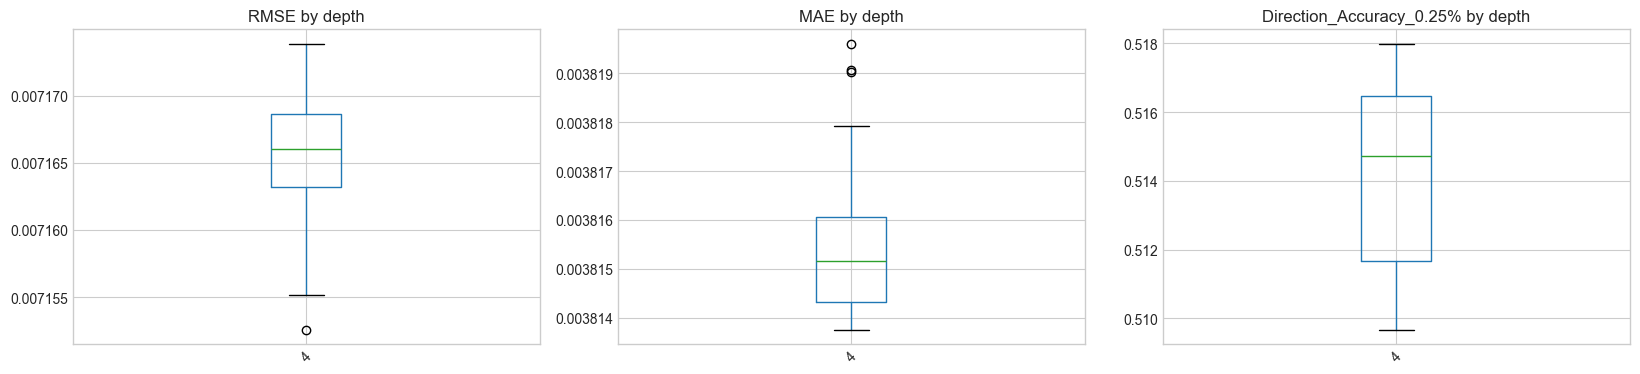

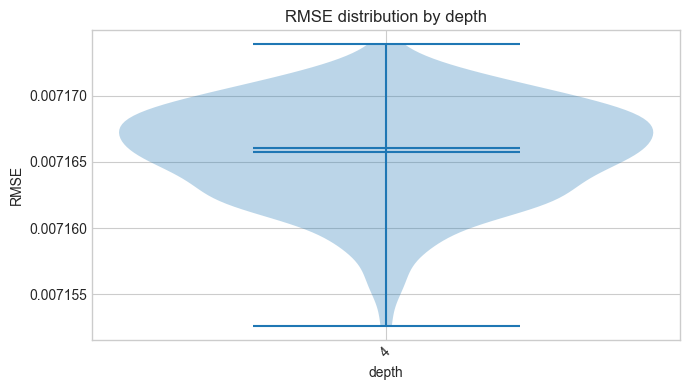

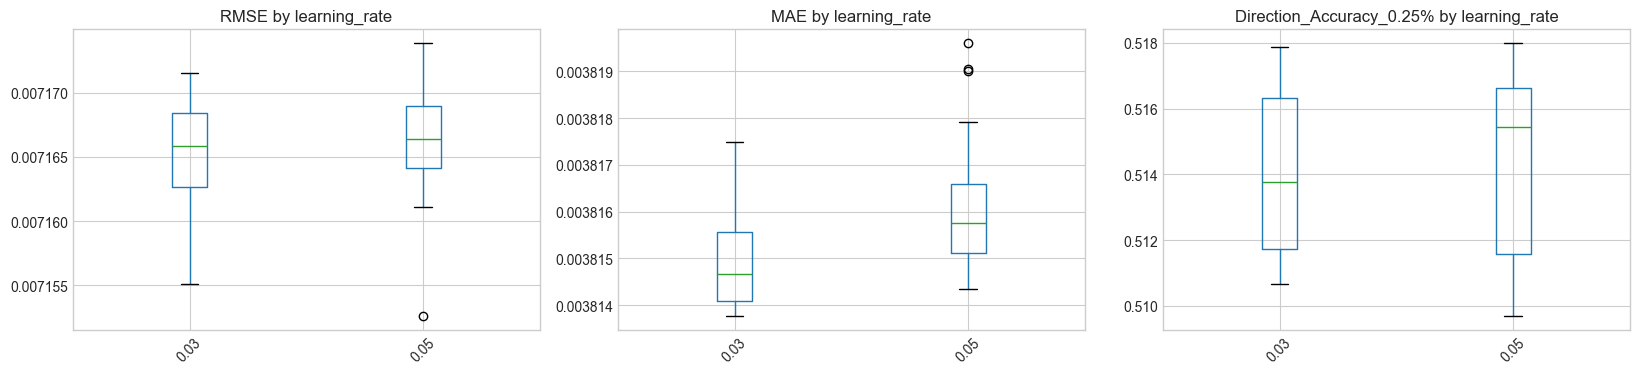

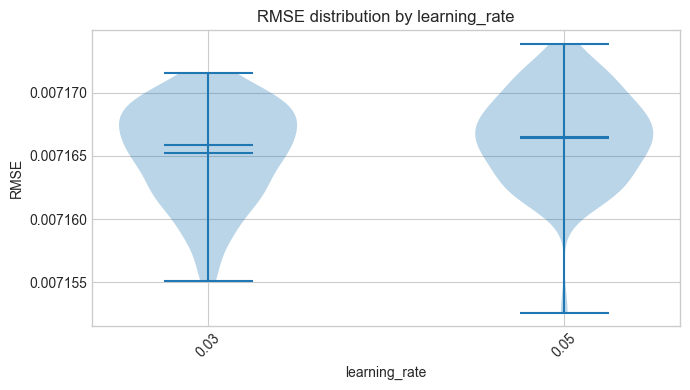

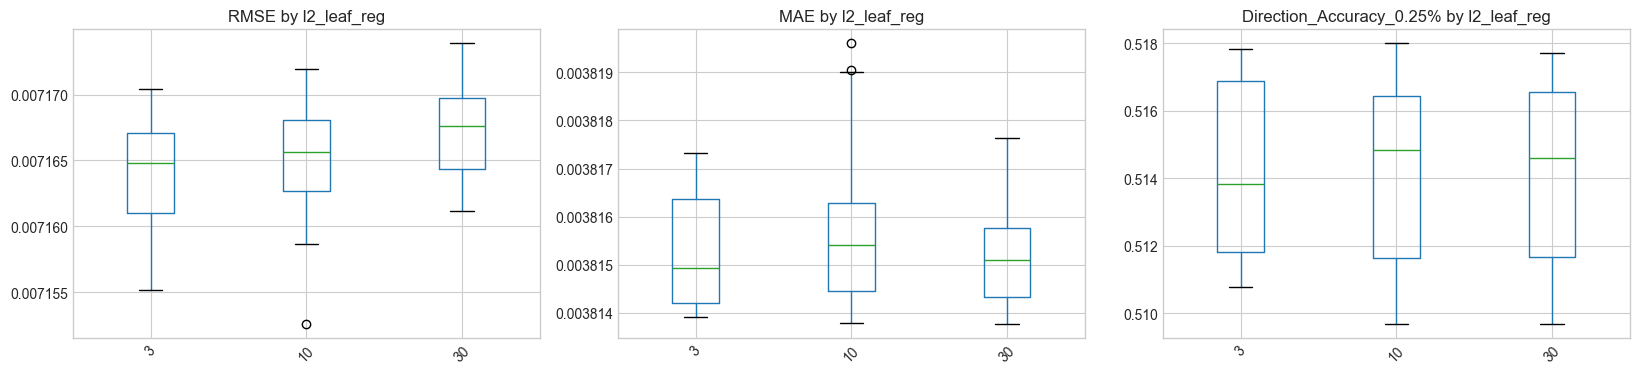

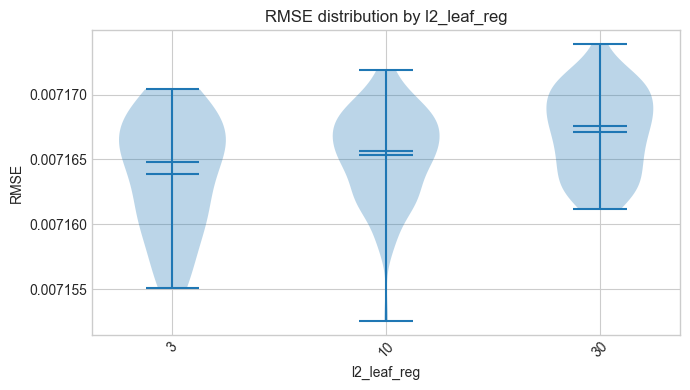

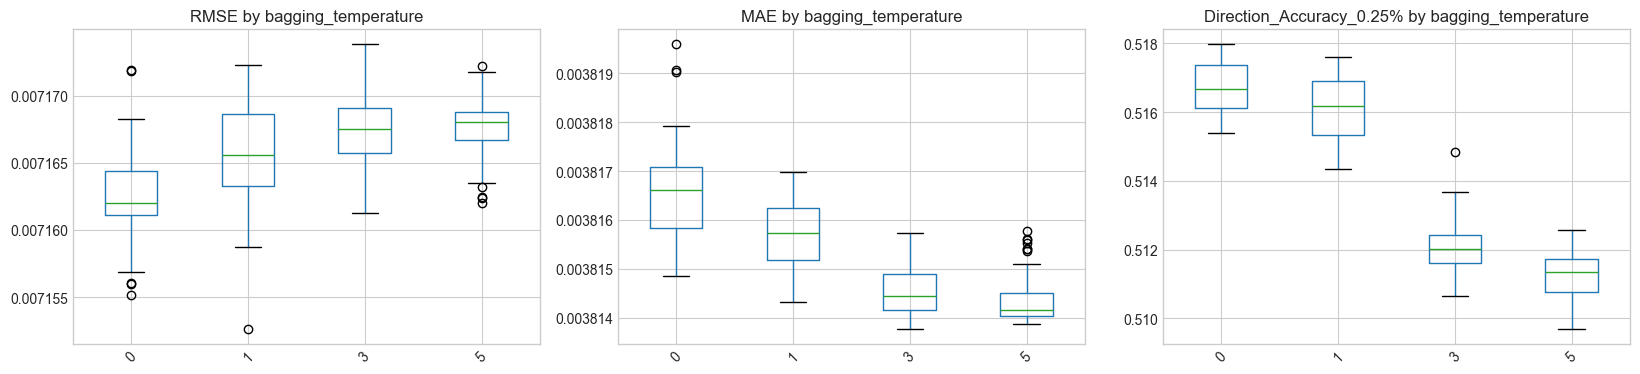

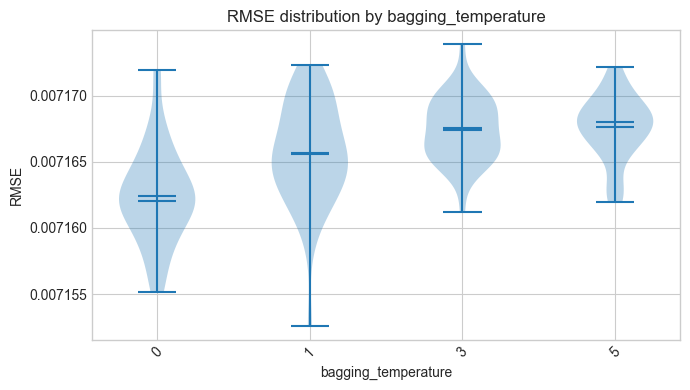

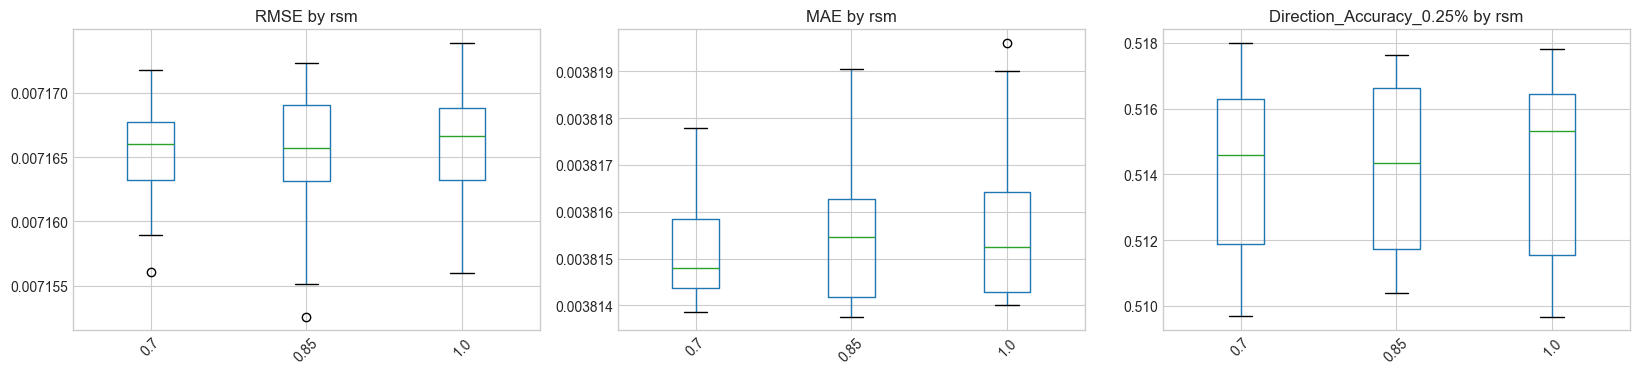

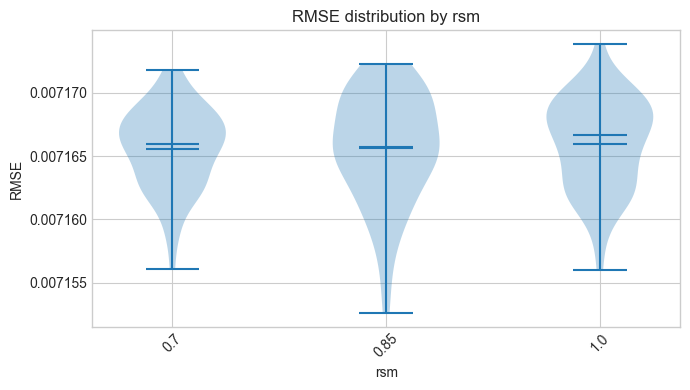

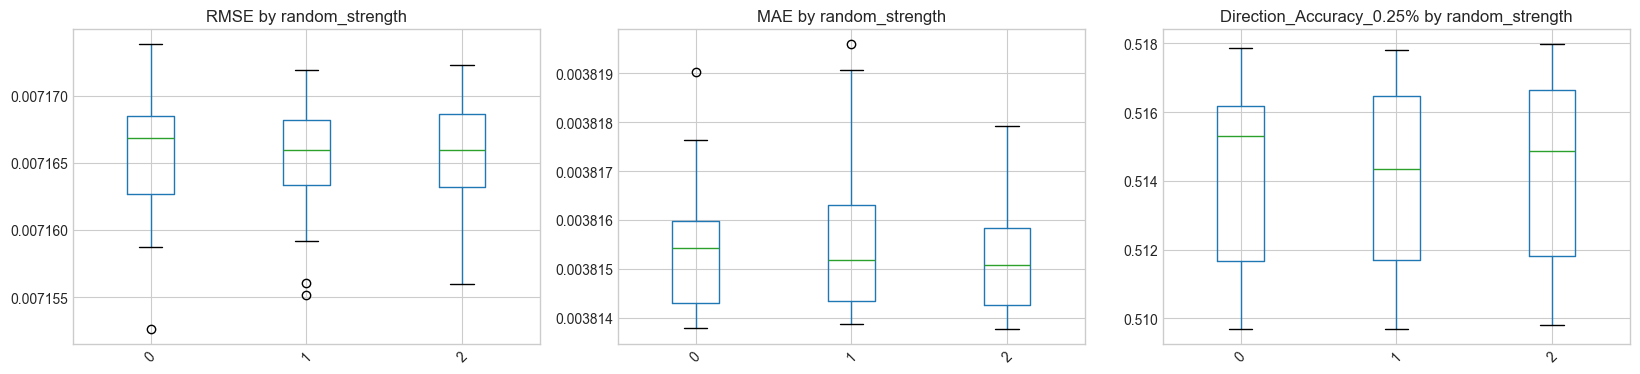

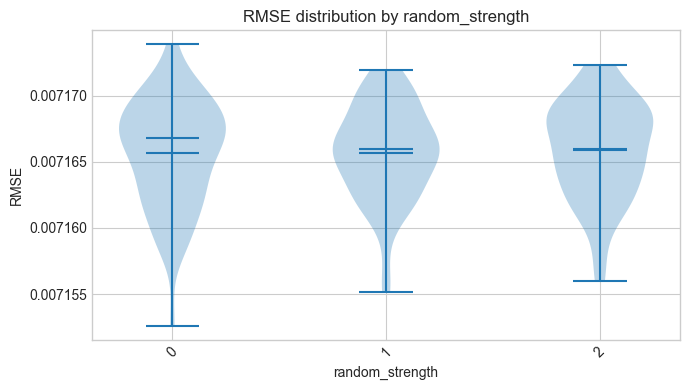

In [9]:
for param in stage2_params:
    print(f"\n{param}")
    display(parameter_summary(results, param, metric="RMSE", top_n=15))
    plot_param_distribution(results, param, metrics=("RMSE", "MAE", "Direction_Accuracy_0.25%"))
    plot_violin_distribution(results, param, metric="RMSE")

## 4. Pairwise Effects

param_rsm,0.70,0.85,1.00
param_bagging_temperature,,,
0,0.007163,0.007162,0.007162
1,0.007169,0.007165,0.007164
3,0.007166,0.007166,0.007170
5,0.007166,0.007169,0.007168


param_random_strength,0,1,2
param_bagging_temperature,,,
0,0.007162,0.007162,0.007163
1,0.007165,0.007166,0.007166
3,0.007167,0.007166,0.007168
5,0.007168,0.007167,0.007168


param_random_strength,0,1,2
param_rsm,,,
0.70,0.007167,0.007166,0.007166
0.85,0.007166,0.007166,0.007165
1.00,0.007166,0.007167,0.007167


param_bagging_temperature,0,1,3,5
param_depth,,,,
4,0.007162,0.007166,0.007168,0.007168


param_bagging_temperature,0,1,3,5
param_learning_rate,,,,
0.03,0.007161,0.007164,0.007168,0.007168
0.05,0.007164,0.007167,0.007167,0.007168


param_rsm,0.70,0.85,1.00
param_l2_leaf_reg,,,
3,0.007166,0.007164,0.007165
10,0.007165,0.007165,0.007167
30,0.007168,0.007168,0.007166


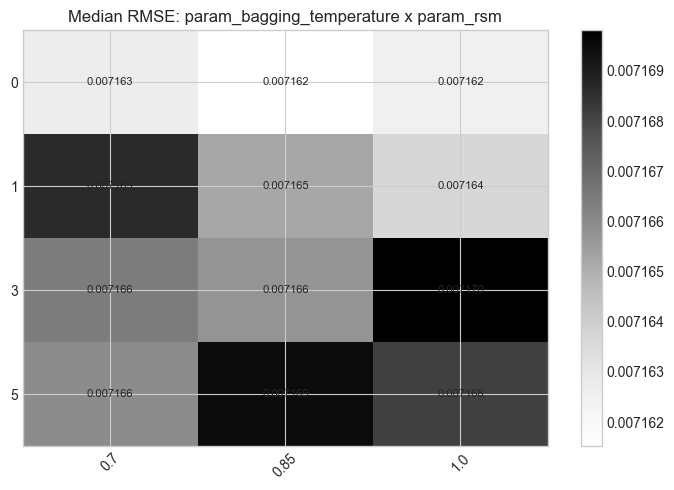

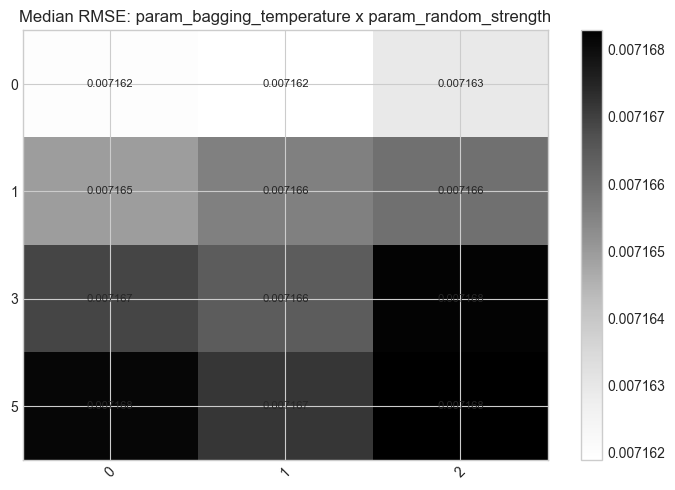

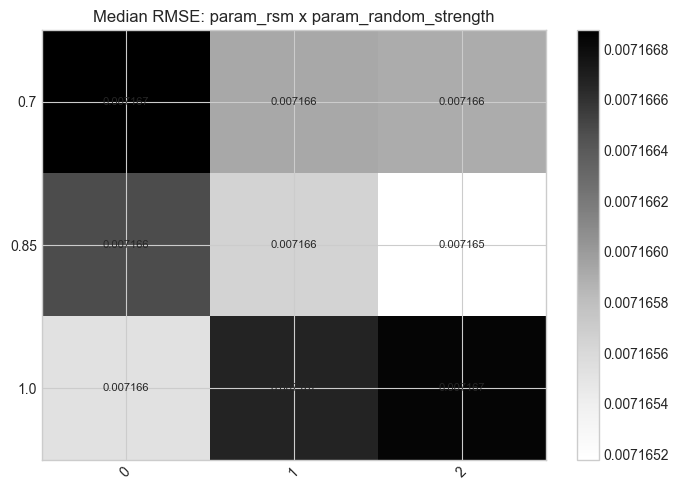

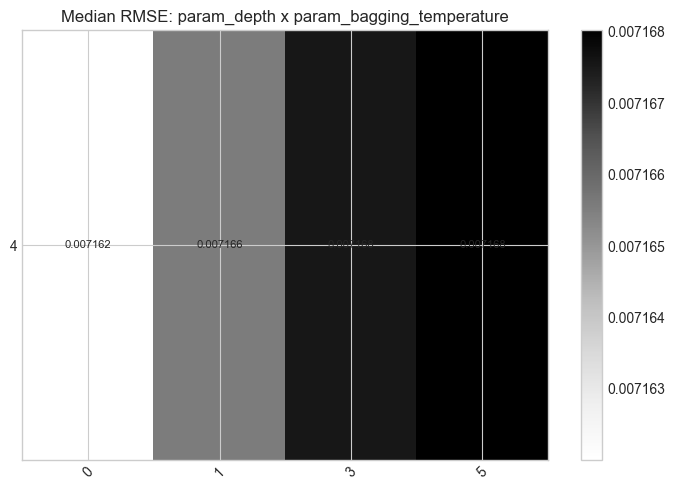

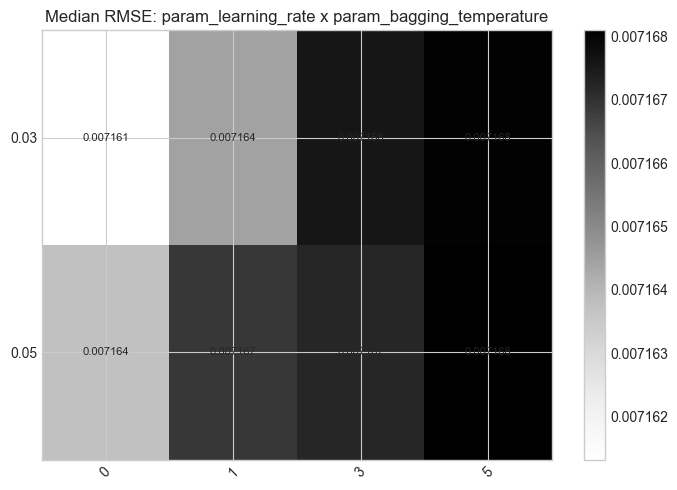

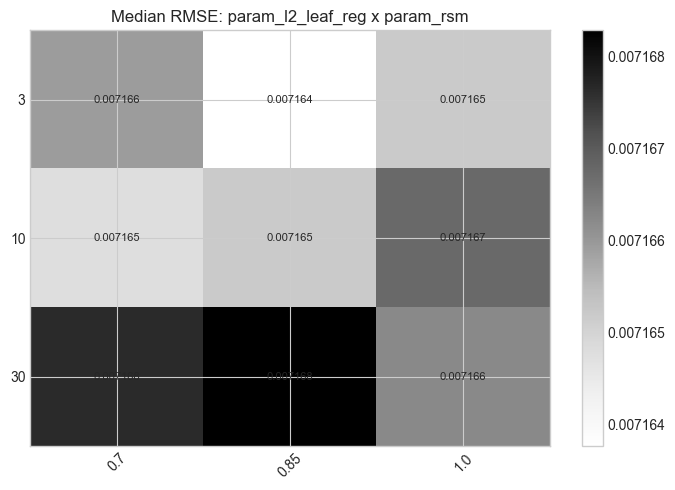

In [10]:
pairs = [
    ("param_bagging_temperature", "param_rsm"),
    ("param_bagging_temperature", "param_random_strength"),
    ("param_rsm", "param_random_strength"),
    ("param_depth", "param_bagging_temperature"),
    ("param_learning_rate", "param_bagging_temperature"),
    ("param_l2_leaf_reg", "param_rsm"),
]

for row_param, col_param in pairs:
    if row_param in results.columns and col_param in results.columns:
        pivot = results.pivot_table(index=row_param, columns=col_param, values="RMSE", aggfunc="median")
        display(pivot)
        plot_heatmap(pivot, title=f"Median RMSE: {row_param} x {col_param}")

## 5. Seed Architecture Comparison

In [11]:
seed_columns = ["param_depth", "param_learning_rate", "param_l2_leaf_reg"]
seed_columns = [column for column in seed_columns if column in results.columns]
seed_summary = (
    results.groupby(seed_columns, dropna=False)
    .agg(
        jobs=("job_id", "count"),
        best_RMSE=("RMSE", "min"),
        median_RMSE=("RMSE", "median"),
        best_DA_025=("Direction_Accuracy_0.25%", "max"),
        median_train_time=("train_time", "median"),
    )
    .reset_index()
    .sort_values(["best_RMSE", "median_RMSE"])
)
seed_summary

,param_depth,param_learning_rate,param_l2_leaf_reg,jobs,best_RMSE,median_RMSE,best_DA_025,median_train_time
3,4,0.05,10,36,0.007153,0.007166,0.517994,1094.932945
0,4,0.03,3,36,0.007155,0.007165,0.517819,1097.999213
1,4,0.03,10,36,0.007159,0.007165,0.517881,1091.092048
4,4,0.05,30,32,0.007161,0.007168,0.517645,1110.176959
2,4,0.03,30,36,0.007162,0.007168,0.517718,1093.725976


## 6. Pareto And Stability

,job_id,RMSE,MAE,Direction_Accuracy_0.25%,train_time,model_size_mb,params
120,catboost_uncertainty_seed04_reg13_d4_lr0.05_l210_bt1_rsm0.85_rs0,0.007153,0.003816,0.517134,1168.919941,0.940632,"{""bagging_temperature"": 1, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.05, ""random_strength"": 0, ""rsm"": 0.85}"
40,catboost_uncertainty_seed02_reg05_d4_lr0.03_l23_bt0_rsm0.85_rs1,0.007155,0.003816,0.517337,1118.245270,0.906410,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 1, ""rsm"": 0.85}"
5,catboost_uncertainty_seed01_reg06_d4_lr0.03_l210_bt0_rsm0.85_rs2,0.007159,0.003816,0.516774,1088.453701,0.904624,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 2, ""rsm"": 0.85}"
15,catboost_uncertainty_seed01_reg16_d4_lr0.03_l210_bt1_rsm1.0_rs0,0.007159,0.003816,0.516462,1063.534721,0.933820,"{""bagging_temperature"": 1, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 1.0}"
42,catboost_uncertainty_seed02_reg07_d4_lr0.03_l23_bt0_rsm1.0_rs0,0.007159,0.003817,0.515646,1060.010721,0.881122,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 1.0}"
16,catboost_uncertainty_seed01_reg17_d4_lr0.03_l210_bt1_rsm1.0_rs1,0.007161,0.003815,0.516048,1055.466188,0.933074,"{""bagging_temperature"": 1, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 1, ""rsm"": 1.0}"
135,catboost_uncertainty_seed04_reg28_d4_lr0.05_l210_bt5_rsm0.7_rs0,0.007162,0.003815,0.509915,1039.953890,0.917226,"{""bagging_temperature"": 5, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.05, ""random_strength"": 0, ""rsm"": 0.7}"
63,catboost_uncertainty_seed02_reg28_d4_lr0.03_l23_bt5_rsm0.7_rs0,0.007166,0.003814,0.511893,1018.611205,0.914544,"{""bagging_temperature"": 5, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 0.7}"
134,catboost_uncertainty_seed04_reg27_d4_lr0.05_l210_bt3_rsm1.0_rs2,0.007166,0.003815,0.512416,937.452474,0.922628,"{""bagging_temperature"": 3, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.05, ""random_strength"": 2, ""rsm"": 1.0}"
70,catboost_uncertainty_seed02_reg35_d4_lr0.03_l23_bt5_rsm1.0_rs1,0.007167,0.003814,0.511490,893.620274,0.905642,"{""bagging_temperature"": 5, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 1, ""rsm"": 1.0}"


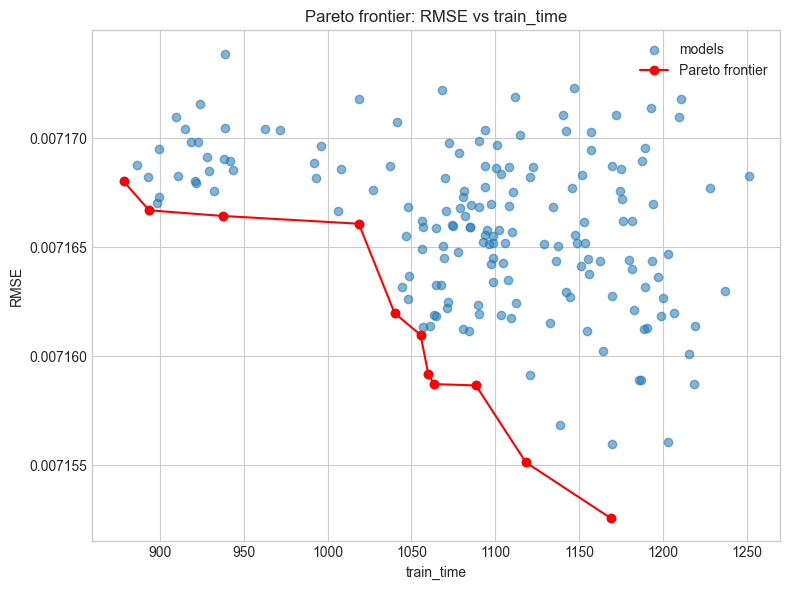

In [12]:
frontier = pareto_frontier(results, quality_metric="RMSE", cost_metric="train_time")
pareto_columns = ["job_id", "RMSE", "MAE", "Direction_Accuracy_0.25%", "train_time", "model_size_mb", "params"]
display(frontier.loc[:, pareto_columns])
plot_pareto(results, frontier, quality_metric="RMSE", cost_metric="train_time")

In [13]:
stability_table(results, metric="RMSE", sizes=(5, 10, 20, 30, 50))

,top_n,rows,best,worst,spread,spread_vs_best_pct,std
0,5,5,0.007153,0.007157,0.000004,0.059819,0.000002
1,10,10,0.007153,0.007159,0.000006,0.088536,0.000002
2,20,20,0.007153,0.007161,0.000009,0.121568,0.000002
3,30,30,0.007153,0.007162,0.000009,0.131064,0.000002
4,50,50,0.007153,0.007164,0.000011,0.154862,0.000002


## 7. Hyperparameter Importance And Correlations

In [14]:
importance, surrogate_model, surrogate_matrix = hyperparameter_importance(
    results,
    metric="RMSE",
    param_cols=stage2_params,
)
importance

,parameter,rf_importance,permutation_importance_mean,permutation_importance_std
2,param_bagging_temperature,0.452630,1.145966,0.140541
3,param_rsm,0.182438,0.420800,0.054195
1,param_l2_leaf_reg,0.156863,0.338823,0.047185
0,param_learning_rate,0.125005,0.188244,0.025090
4,param_random_strength,0.083063,0.107422,0.023147


In [15]:
parameter_correlations(results)

,parameter,target,spearman,pearson
2,param_bagging_temperature,Direction_Accuracy_0.25%,-0.874419,-0.919481
1,param_bagging_temperature,MAE,-0.773425,-0.727840
23,param_rsm,train_time,-0.623600,-0.632313
3,param_bagging_temperature,train_time,-0.585061,-0.604115
0,param_bagging_temperature,RMSE,0.518251,0.480880
11,param_learning_rate,MAE,0.440981,0.421519
14,param_learning_rate,model_size_mb,0.298811,0.314667
5,param_l2_leaf_reg,RMSE,0.282273,0.310702
24,param_rsm,model_size_mb,-0.253741,-0.264731
10,param_learning_rate,RMSE,0.139644,0.159739


## 8. HMM Feature Importance

In [16]:
def load_feature_importance(row: pd.Series) -> pd.DataFrame:
    key = row.get("feature_importance_key")
    if not isinstance(key, str) or not key:
        return pd.DataFrame()
    frame = read_parquet(s3, BUCKET, key)
    if frame.empty:
        return frame
    frame = frame.copy()
    frame["job_id"] = row["job_id"]
    frame["RMSE"] = row["RMSE"]
    return frame


top_for_importance = results.sort_values(["RMSE", "MAE", "job_id"]).head(15)
feature_importance = pd.concat(
    [load_feature_importance(row) for _, row in top_for_importance.iterrows()],
    ignore_index=True,
) if len(top_for_importance) else pd.DataFrame()

if feature_importance.empty:
    print("No feature importance data loaded yet.")
else:
    feature_importance["importance_abs"] = feature_importance["importance"].abs()
    aggregate_importance = (
        feature_importance.groupby("feature", as_index=False)
        .agg(mean_abs_importance=("importance_abs", "mean"), jobs=("job_id", "nunique"))
        .sort_values("mean_abs_importance", ascending=False)
    )
    display(aggregate_importance.head(30))
    display(aggregate_importance.loc[aggregate_importance["feature"].str.startswith("price_hmm_n4_")])

,feature,mean_abs_importance,jobs
57,price_hmm_n4_prob_state_3,20.953637,15
56,price_hmm_n4_prob_state_2,20.685719,15
31,ada_realized_volatility_60m,17.402059,15
36,ada_return_std_60m,11.346057,15
30,ada_realized_volatility_20m,2.537706,15
38,ada_trades_per_minute_5m,1.866918,15
58,time_of_day_cos,1.773252,15
55,price_hmm_n4_prob_state_1,1.671959,15
59,time_of_day_sin,1.511572,15
35,ada_return_std_20m,1.399949,15


,feature,mean_abs_importance,jobs
57,price_hmm_n4_prob_state_3,20.953637,15
56,price_hmm_n4_prob_state_2,20.685719,15
55,price_hmm_n4_prob_state_1,1.671959,15
54,price_hmm_n4_prob_state_0,1.364041,15


## 9. Early-Stop Diagnostic

,models_seen,job_id,RMSE,best_so_far
0,1,catboost_uncertainty_seed01_reg01_d4_lr0.03_l210_bt0_rsm0.7_rs0,0.007159,0.007159
3,2,catboost_uncertainty_seed01_reg04_d4_lr0.03_l210_bt0_rsm0.85_rs0,0.007161,0.007159
1,3,catboost_uncertainty_seed01_reg02_d4_lr0.03_l210_bt0_rsm0.7_rs1,0.007163,0.007159
2,4,catboost_uncertainty_seed01_reg03_d4_lr0.03_l210_bt0_rsm0.7_rs2,0.007161,0.007159
7,5,catboost_uncertainty_seed01_reg08_d4_lr0.03_l210_bt0_rsm1.0_rs1,0.007167,0.007159
6,6,catboost_uncertainty_seed01_reg07_d4_lr0.03_l210_bt0_rsm1.0_rs0,0.007162,0.007159
5,7,catboost_uncertainty_seed01_reg06_d4_lr0.03_l210_bt0_rsm0.85_rs2,0.007159,0.007159
4,8,catboost_uncertainty_seed01_reg05_d4_lr0.03_l210_bt0_rsm0.85_rs1,0.007159,0.007159
8,9,catboost_uncertainty_seed01_reg09_d4_lr0.03_l210_bt0_rsm1.0_rs2,0.007165,0.007159
9,10,catboost_uncertainty_seed01_reg10_d4_lr0.03_l210_bt1_rsm0.7_rs0,0.007167,0.007159


,models_seen,job_id,RMSE,best_so_far
156,157,catboost_uncertainty_seed05_reg13_d4_lr0.05_l230_bt1_rsm0.85_rs0,0.007166,0.007153
157,158,catboost_uncertainty_seed05_reg14_d4_lr0.05_l230_bt1_rsm0.85_rs1,0.007171,0.007153
158,159,catboost_uncertainty_seed05_reg15_d4_lr0.05_l230_bt1_rsm0.85_rs2,0.007172,0.007153
159,160,catboost_uncertainty_seed05_reg16_d4_lr0.05_l230_bt1_rsm1.0_rs0,0.007164,0.007153
160,161,catboost_uncertainty_seed05_reg17_d4_lr0.05_l230_bt1_rsm1.0_rs1,0.007166,0.007153
161,162,catboost_uncertainty_seed05_reg18_d4_lr0.05_l230_bt1_rsm1.0_rs2,0.007168,0.007153
162,163,catboost_uncertainty_seed05_reg19_d4_lr0.05_l230_bt3_rsm0.7_rs0,0.007167,0.007153
163,164,catboost_uncertainty_seed05_reg20_d4_lr0.05_l230_bt3_rsm0.7_rs1,0.007168,0.007153
164,165,catboost_uncertainty_seed05_reg21_d4_lr0.05_l230_bt3_rsm0.7_rs2,0.007165,0.007153
165,166,catboost_uncertainty_seed05_reg22_d4_lr0.05_l230_bt3_rsm0.85_rs0,0.007168,0.007153


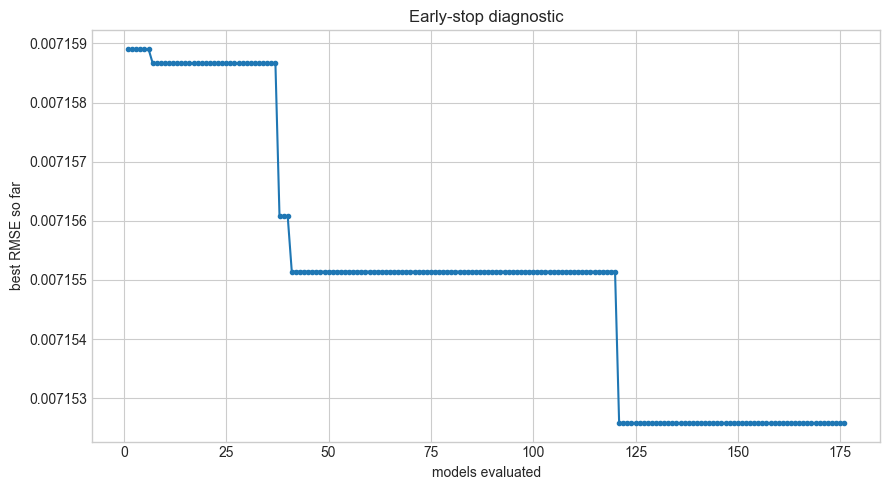

In [17]:
curve = early_stop_curve(results, metric="RMSE")
display(curve.head(20))
display(curve.tail(20))
plot_early_stop(curve, metric="RMSE")

## 10. Stage 3 Candidate Selection

In [18]:
selection_columns = [
    "job_id",
    "RMSE",
    "MAE",
    "Direction_Accuracy_0.25%",
    "CompositeScore",
    "train_time",
    "model_size_mb",
    "params",
]

stage3_by_rmse = results.sort_values(["RMSE", "MAE", "job_id"]).loc[:, selection_columns].head(10)
stage3_by_direction = results.sort_values(
    ["Direction_Accuracy_0.25%", "RMSE", "job_id"],
    ascending=[False, True, True],
).loc[:, selection_columns].head(10)
stage3_by_composite = results.sort_values(
    ["CompositeScore", "RMSE", "job_id"],
    ascending=[False, True, True],
).loc[:, selection_columns].head(10)

print("Top by RMSE")
display(stage3_by_rmse)
print("Top by Direction Accuracy 0.25%")
display(stage3_by_direction)
print("Top by Composite Score")
display(stage3_by_composite)

Top by RMSE


,job_id,RMSE,MAE,Direction_Accuracy_0.25%,CompositeScore,train_time,model_size_mb,params
120,catboost_uncertainty_seed04_reg13_d4_lr0.05_l210_bt1_rsm0.85_rs0,0.007153,0.003816,0.517134,0.784571,1168.919941,0.940632,"{""bagging_temperature"": 1, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.05, ""random_strength"": 0, ""rsm"": 0.85}"
40,catboost_uncertainty_seed02_reg05_d4_lr0.03_l23_bt0_rsm0.85_rs1,0.007155,0.003816,0.517337,0.788143,1118.245270,0.906410,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 1, ""rsm"": 0.85}"
44,catboost_uncertainty_seed02_reg09_d4_lr0.03_l23_bt0_rsm1.0_rs2,0.007156,0.003816,0.516945,0.746857,1169.453877,0.889246,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 2, ""rsm"": 1.0}"
37,catboost_uncertainty_seed02_reg02_d4_lr0.03_l23_bt0_rsm0.7_rs1,0.007156,0.003816,0.517515,0.763714,1202.929061,0.914604,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 1, ""rsm"": 0.7}"
41,catboost_uncertainty_seed02_reg06_d4_lr0.03_l23_bt0_rsm0.85_rs2,0.007157,0.003817,0.517362,0.747714,1138.517147,0.905601,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 2, ""rsm"": 0.85}"
5,catboost_uncertainty_seed01_reg06_d4_lr0.03_l210_bt0_rsm0.85_rs2,0.007159,0.003816,0.516774,0.740429,1088.453701,0.904624,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 2, ""rsm"": 0.85}"
15,catboost_uncertainty_seed01_reg16_d4_lr0.03_l210_bt1_rsm1.0_rs0,0.007159,0.003816,0.516462,0.744429,1063.534721,0.933820,"{""bagging_temperature"": 1, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 1.0}"
39,catboost_uncertainty_seed02_reg04_d4_lr0.03_l23_bt0_rsm0.85_rs0,0.007159,0.003817,0.517253,0.741286,1218.497837,0.896028,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 0.85}"
0,catboost_uncertainty_seed01_reg01_d4_lr0.03_l210_bt0_rsm0.7_rs0,0.007159,0.003815,0.517881,0.867714,1186.850101,0.908237,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 0.7}"
36,catboost_uncertainty_seed02_reg01_d4_lr0.03_l23_bt0_rsm0.7_rs0,0.007159,0.003816,0.517377,0.781571,1185.738914,0.906891,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 0.7}"


Top by Direction Accuracy 0.25%


,job_id,RMSE,MAE,Direction_Accuracy_0.25%,CompositeScore,train_time,model_size_mb,params
110,catboost_uncertainty_seed04_reg03_d4_lr0.05_l210_bt0_rsm0.7_rs2,0.007167,0.003818,0.517994,0.489143,1194.116553,0.927015,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.05, ""random_strength"": 2, ""rsm"": 0.7}"
0,catboost_uncertainty_seed01_reg01_d4_lr0.03_l210_bt0_rsm0.7_rs0,0.007159,0.003815,0.517881,0.867714,1186.850101,0.908237,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 0.7}"
43,catboost_uncertainty_seed02_reg08_d4_lr0.03_l23_bt0_rsm1.0_rs1,0.007161,0.003817,0.517819,0.709286,1057.049303,0.891740,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 1, ""rsm"": 1.0}"
80,catboost_uncertainty_seed03_reg09_d4_lr0.03_l230_bt0_rsm1.0_rs2,0.007164,0.003815,0.517718,0.712429,1181.254865,0.886583,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03, ""random_strength"": 2, ""rsm"": 1.0}"
146,catboost_uncertainty_seed05_reg03_d4_lr0.05_l230_bt0_rsm0.7_rs2,0.007172,0.003817,0.517645,0.326143,1210.893395,0.928341,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.05, ""random_strength"": 2, ""rsm"": 0.7}"
113,catboost_uncertainty_seed04_reg06_d4_lr0.05_l210_bt0_rsm0.85_rs2,0.007161,0.003818,0.517623,0.712143,1154.494939,0.925041,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.05, ""random_strength"": 2, ""rsm"": 0.85}"
158,catboost_uncertainty_seed05_reg15_d4_lr0.05_l230_bt1_rsm0.85_rs2,0.007172,0.003816,0.517609,0.357286,1146.800400,0.941951,"{""bagging_temperature"": 1, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.05, ""random_strength"": 2, ""rsm"": 0.85}"
37,catboost_uncertainty_seed02_reg02_d4_lr0.03_l23_bt0_rsm0.7_rs1,0.007156,0.003816,0.517515,0.763714,1202.929061,0.914604,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 1, ""rsm"": 0.7}"
1,catboost_uncertainty_seed01_reg02_d4_lr0.03_l210_bt0_rsm0.7_rs1,0.007163,0.003816,0.517453,0.700286,1189.063590,0.912704,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 1, ""rsm"": 0.7}"
3,catboost_uncertainty_seed01_reg04_d4_lr0.03_l210_bt0_rsm0.85_rs0,0.007161,0.003816,0.517435,0.719857,1188.810372,0.898908,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 0.85}"


Top by Composite Score


,job_id,RMSE,MAE,Direction_Accuracy_0.25%,CompositeScore,train_time,model_size_mb,params
0,catboost_uncertainty_seed01_reg01_d4_lr0.03_l210_bt0_rsm0.7_rs0,0.007159,0.003815,0.517881,0.867714,1186.850101,0.908237,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 0.7}"
89,catboost_uncertainty_seed03_reg18_d4_lr0.03_l230_bt1_rsm1.0_rs2,0.007162,0.003814,0.516967,0.816857,1064.490483,0.932968,"{""bagging_temperature"": 1, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03, ""random_strength"": 2, ""rsm"": 1.0}"
40,catboost_uncertainty_seed02_reg05_d4_lr0.03_l23_bt0_rsm0.85_rs1,0.007155,0.003816,0.517337,0.788143,1118.245270,0.906410,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 1, ""rsm"": 0.85}"
120,catboost_uncertainty_seed04_reg13_d4_lr0.05_l210_bt1_rsm0.85_rs0,0.007153,0.003816,0.517134,0.784571,1168.919941,0.940632,"{""bagging_temperature"": 1, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.05, ""random_strength"": 0, ""rsm"": 0.85}"
36,catboost_uncertainty_seed02_reg01_d4_lr0.03_l23_bt0_rsm0.7_rs0,0.007159,0.003816,0.517377,0.781571,1185.738914,0.906891,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 0, ""rsm"": 0.7}"
59,catboost_uncertainty_seed02_reg24_d4_lr0.03_l23_bt3_rsm0.85_rs2,0.007161,0.003814,0.512749,0.777000,1080.721717,0.923820,"{""bagging_temperature"": 3, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 2, ""rsm"": 0.85}"
16,catboost_uncertainty_seed01_reg17_d4_lr0.03_l210_bt1_rsm1.0_rs1,0.007161,0.003815,0.516048,0.769429,1055.466188,0.933074,"{""bagging_temperature"": 1, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03, ""random_strength"": 1, ""rsm"": 1.0}"
37,catboost_uncertainty_seed02_reg02_d4_lr0.03_l23_bt0_rsm0.7_rs1,0.007156,0.003816,0.517515,0.763714,1202.929061,0.914604,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 1, ""rsm"": 0.7}"
41,catboost_uncertainty_seed02_reg06_d4_lr0.03_l23_bt0_rsm0.85_rs2,0.007157,0.003817,0.517362,0.747714,1138.517147,0.905601,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 2, ""rsm"": 0.85}"
44,catboost_uncertainty_seed02_reg09_d4_lr0.03_l23_bt0_rsm1.0_rs2,0.007156,0.003816,0.516945,0.746857,1169.453877,0.889246,"{""bagging_temperature"": 0, ""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03, ""random_strength"": 2, ""rsm"": 1.0}"


Recommended Stage 3 policy:

- Use the Top RMSE and Top Composite tables as the main candidate source.
- Keep separate direction-accuracy candidates if trading direction matters more than point RMSE.
- If the run is still partial, do not finalize Stage 3 until `completed_jobs == run_config['jobs']` or the remaining seed regions are known to be irrelevant.